In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [1]:
# Create your first MLP in Keras
from keras.models import Sequential
from keras.layers import Dense
import numpy

In [6]:
# fix random seed for reproducibility
#seed = 7
#numpy.random.seed(seed)
# load pima indians dataset

#dataset = numpy.loadtxt("pima-indians-diabetes.data.csv", delimiter=",")

import pandas as pd
df = pd.read_csv("pima-indians-diabetes.csv")
# split into input (X) and output (Y) variables
X = df.iloc[:,0:8]
Y = df.iloc[:,8]


In [13]:
df.shape

(768, 9)

In [5]:
df.head()

,X1_1,X1_2,X1_3,X1_4,X1_5,X1_6,X1_7,X1_8,Y
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X.head()

,X1_1,X1_2,X1_3,X1_4,X1_5,X1_6,X1_7,X1_8
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [8]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Y, dtype: int64

In [10]:
# create model
model = Sequential()
model.add(Dense(8)) #1st layer
model.add(Dense(12,  activation='relu')) #2nd layer
model.add(Dense(1, activation='sigmoid')) #3rd layer or op layer

![image.png](attachment:image.png)

In [11]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
# Fit the model
history = model.fit(X, Y, validation_split=0.30, epochs=250, batch_size=10)

Epoch 1/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.3780 - loss: 17.3635 - val_accuracy: 0.5801 - val_loss: 4.1835
Epoch 2/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4134 - loss: 3.0818 - val_accuracy: 0.4156 - val_loss: 2.3007
Epoch 3/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4078 - loss: 2.1303 - val_accuracy: 0.5238 - val_loss: 1.7295
Epoch 4/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4972 - loss: 1.5764 - val_accuracy: 0.5325 - val_loss: 1.3210
Epoch 5/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4953 - loss: 1.2570 - val_accuracy: 0.6190 - val_loss: 1.1156
Epoch 6/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5605 - loss: 1.0252 - val_accuracy: 0.5411 - val_loss: 0.9980
Epoch 7/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5736 - loss: 0.9046 - val_accuracy: 0.4502 - val_loss: 1.0399
Epoch 8/250
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6350 - loss: 0.7915 - val_accuracy: 0.6580 -

In [14]:
768*0.7

537.5999999999999

In [16]:
# evaluate the model
scores = model.evaluate(X, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7214 - loss: 0.5626 
compile_metrics: 72.14%


In [17]:
# Visualize training history

# list all data in history
history.history.keys()



dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

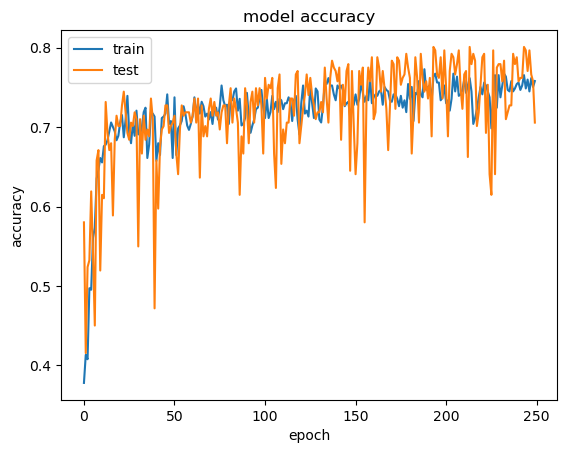

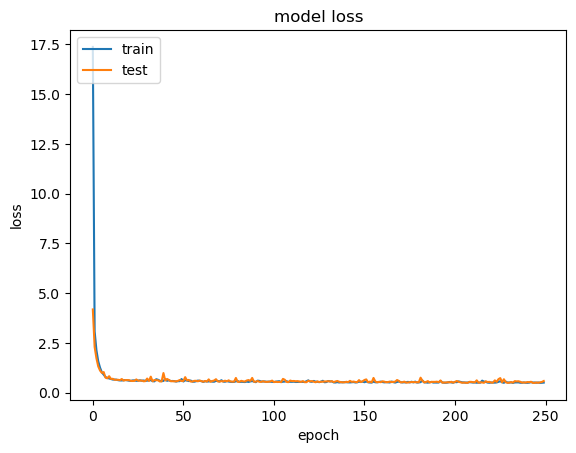

In [18]:
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
